In [1]:
import pandas as pd

df = pd.read_csv("../data/churn.csv")

# Basic checks
print(df.head())
print(df.info())
print(df.describe())

# Target column check
print(df["Churn"].value_counts())

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

In [2]:
# Fix TotalCharges issue
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Drop missing values
df.dropna(inplace=True)

In [3]:
df = pd.get_dummies(df, drop_first=True)

In [19]:
df.to_csv("../data/cleaned_churn.csv", index=False)

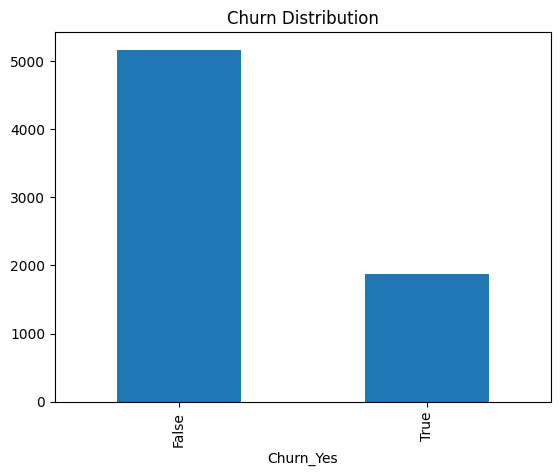

In [5]:
import matplotlib.pyplot as plt

df = pd.read_csv("../data/cleaned_churn.csv")
df["Churn_Yes"].value_counts()
df["Churn_Yes"].value_counts().plot(kind="bar", title="Churn Distribution")
plt.show()

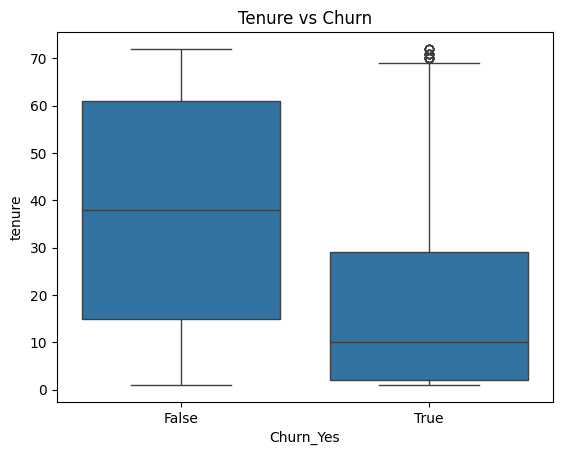

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x=df["Churn_Yes"], y=df["tenure"])
plt.title("Tenure vs Churn")
plt.show()

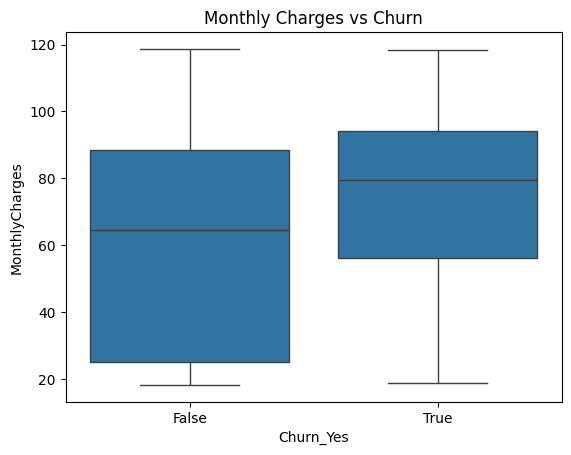

In [8]:
sns.boxplot(x=df["Churn_Yes"], y=df["MonthlyCharges"])
plt.title("Monthly Charges vs Churn")
plt.show()

In [9]:
contract_cols = [col for col in df.columns if "Contract" in col]

for col in contract_cols:
    print(col, df.groupby(col)["Churn_Yes"].mean())

Contract_One year Contract_One year
False    0.306295
True     0.112772
Name: Churn_Yes, dtype: float64
Contract_Two year Contract_Two year
False    0.340565
True     0.028487
Name: Churn_Yes, dtype: float64


In [ ]:
# plt.figure(figsize=(12,8))
# sns.heatmap(df.corr(), cmap="coolwarm")
# plt.title("Correlation Heatmap")
# plt.show()

In [6]:
X = df.drop("Churn_Yes", axis=1)
y = df["Churn_Yes"]

In [7]:
# Train-test split
from sklearn.model_selection import train_test_split

X = df.drop("Churn_Yes", axis=1)
y = df["Churn_Yes"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [8]:
# Logistic Regression
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test) 

d:\data_analytics\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [9]:
from sklearn.metrics import classification_report, confusion_matrix

print("Logistic Regression Results:\n")
print(confusion_matrix(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

Logistic Regression Results:

[[902 131]
 [169 205]]
              precision    recall  f1-score   support

       False       0.84      0.87      0.86      1033
        True       0.61      0.55      0.58       374

    accuracy                           0.79      1407
   macro avg       0.73      0.71      0.72      1407
weighted avg       0.78      0.79      0.78      1407



In [10]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest Results:\n")
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest Results:

[[944  89]
 [215 159]]
              precision    recall  f1-score   support

       False       0.81      0.91      0.86      1033
        True       0.64      0.43      0.51       374

    accuracy                           0.78      1407
   macro avg       0.73      0.67      0.69      1407
weighted avg       0.77      0.78      0.77      1407



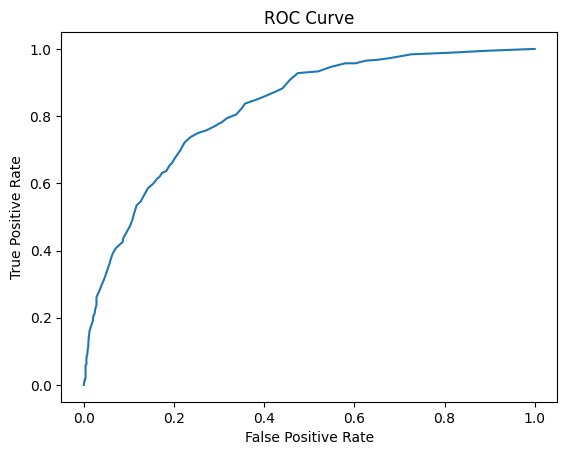

AUC Score: 0.8239823783073028


In [11]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

y_prob = rf.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

print("AUC Score:", roc_auc_score(y_test, y_prob))

<Axes: >

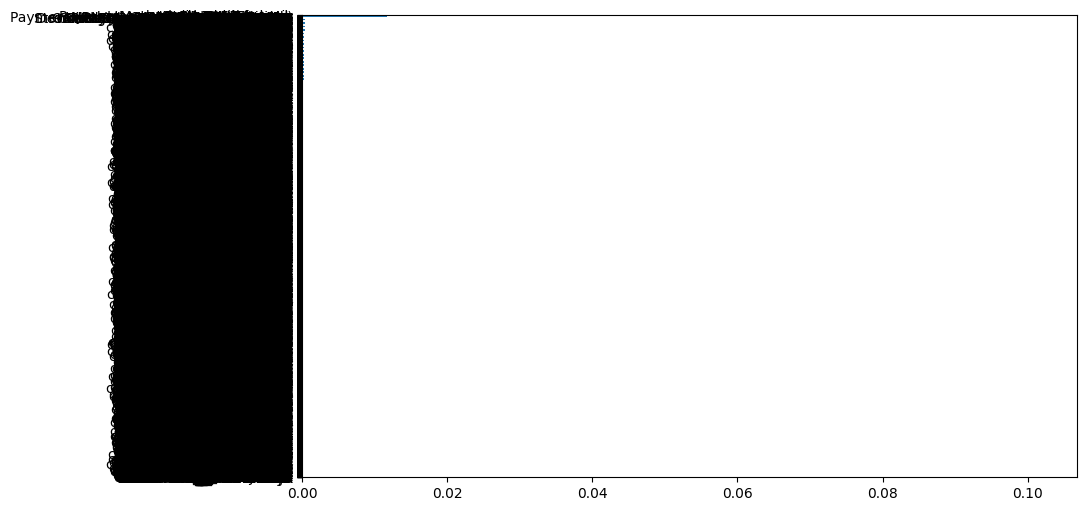

In [12]:
import pandas as pd

importance = pd.Series(rf.feature_importances_, index=X.columns)
importance.sort_values().plot(kind="barh", figsize=(10,6))

In [13]:
df["churn_prob"] = rf.predict_proba(X)[:,1]

C:\Users\hgrak\AppData\Local\Temp\ipykernel_12336\3735629205.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["churn_prob"] = rf.predict_proba(X)[:,1]


In [14]:
def segment(p):
    if p > 0.7:
        return "High Risk"
    elif p > 0.4:
        return "Medium Risk"
    else:
        return "Low Risk"

df["risk_segment"] = df["churn_prob"].apply(segment)

C:\Users\hgrak\AppData\Local\Temp\ipykernel_12336\2446886396.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["risk_segment"] = df["churn_prob"].apply(segment)


<Axes: title={'center': 'Customer Risk Segments'}, xlabel='risk_segment'>

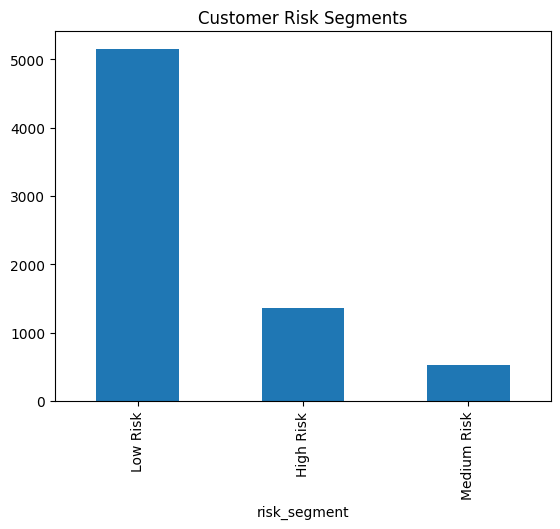

In [15]:
df["risk_segment"].value_counts().plot(kind="bar", title="Customer Risk Segments")

In [16]:
high_risk = df[df["risk_segment"] == "High Risk"]

print("High risk customers:", len(high_risk))

High risk customers: 1356


In [ ]:
import joblib

joblib.dump(rf, "../models/rf_model.pkl")

FileNotFoundError: [Errno 2] No such file or directory: '../churn-project/models/rf_model.pkl'